In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
df1 = pd.read_excel(r"C:\Data Analyst\online_retail_II.xlsx", sheet_name='Year 2009-2010')

df2 = pd.read_excel(r"C:\Data Analyst\online_retail_II.xlsx", sheet_name='Year 2010-2011')

In [9]:
df = pd.concat([df1,df2],ignore_index=True)

df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [10]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [11]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


## Exploratory Data Analysis


In [13]:
# check for null
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [14]:
df.shape

(1067371, 8)

In [20]:
df = df[(df['Quantity']>0) & (df['Price']>0)]

In [15]:
#drop null value in Customer ID

df = df.dropna(subset=['Customer ID'])

In [16]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,824364.000000,824364,824364.000000,824364.000000
mean,12.414574,2011-01-01 22:29:28.042054144,3.676800,15324.638504
min,-80995.000000,2009-12-01 07:45:00,0.000000,12346.000000
25%,2.000000,2010-07-06 11:58:00,1.250000,13975.000000
50%,5.000000,2010-12-03 14:26:00,1.950000,15255.000000
75%,12.000000,2011-07-27 15:14:00,3.750000,16797.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,188.976099,NaN,70.241388,1697.464450


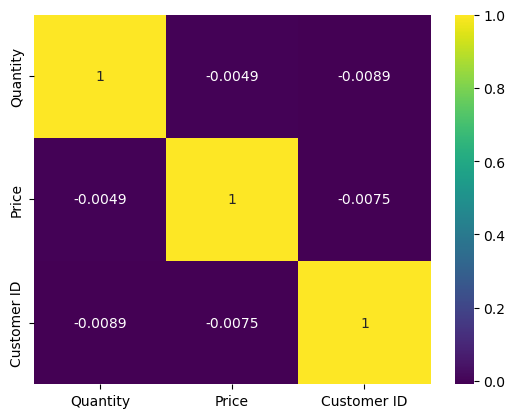

In [21]:
# correlation
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='viridis')
plt.show()

In [22]:
# create a spent column for monetary clustering
df['Money Spent']= df['Quantity'] * df['Price']

In [23]:
df.head(1)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Money Spent
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4


In [24]:
# Establish a snapshot day.
# I choose a day after the last order was made

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [34]:
# Recency, Frequency & Monetary
rfm = df.groupby('Customer ID').agg({'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
                                    'Invoice': 'nunique',
                                    'Money Spent': 'sum'}).reset_index()

In [36]:
rfm.columns = ['Customer ID', 'recency', 'frequency', 'monetary']

In [28]:
rfm

,Customer ID,recency,frequency,monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,5633.32
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40
...,...,...,...,...
5873,18283.0,4,22,2736.65
5874,18284.0,432,1,461.68
5875,18285.0,661,1,427.00
5876,18286.0,477,2,1296.43


<function matplotlib.pyplot.show(close=None, block=None)>

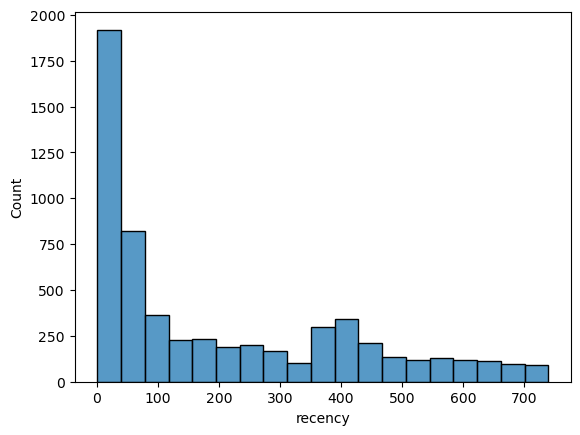

In [52]:
#checking for skewness

sns.histplot(rfm['recency'])
plt.show

In [45]:
rfm['frequency'].mean()

np.float64(6.289384144266758)

In [47]:
rfm['frequency'].median()

3.0

In [48]:
# For a right skew (positive skew) the mean is greater than the median

In [49]:
rfm.columns 

Index(['Customer ID', 'recency', 'frequency', 'monetary'], dtype='object')

In [56]:
# We do logarithm transformation for the skewed columns

rfm_log = np.log1p(rfm[['recency', 'frequency', 'monetary']])

In [57]:
# Standardize features

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

In [97]:
df_scaled = pd.DataFrame(rfm_scaled, columns=['recency', 'frequency', 'monetary'])

In [61]:
df_scaled.head()

,recency,frequency,monetary
0,0.856701,1.254496,3.186625
1,-2.151979,0.800166,1.297127
2,-0.079138,0.299207,0.558100
3,-0.935308,0.073946,1.123790
4,0.824527,-1.058146,-0.735888


In [71]:
# Deterining the number of clustering

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, n_init=10, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

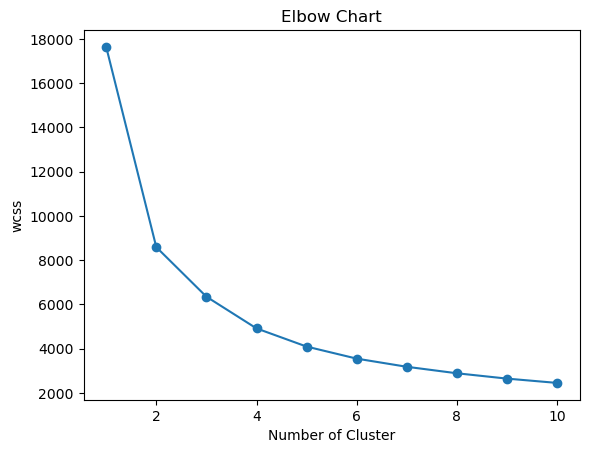

In [72]:
#plot the elbow chart
plt.plot(range(1,11),wcss, marker='o')
plt.title('Elbow Chart')
plt.xlabel('Number of Cluster')
plt.ylabel('wcss')
plt.show()

In [ ]:
# From the elbow chart, the K value is 3

In [ ]:
# Retraining the model

In [81]:
kmeans = KMeans(n_clusters=3, n_init=3, random_state=42)


In [82]:
# fit & predict

rfm['cluster']= kmeans.fit_predict(df_scaled)


In [100]:
cluster_profile = rfm.groupby('cluster').agg({'recency': 'mean', 'frequency': 'mean', 'monetary': ['mean', 'count']}).round(2)

cluster_profile

recency frequency  monetary      
           mean      mean      mean count
cluster                                  
0        372.11      1.55    405.77  2424
1         32.83     19.65  11203.90  1173
2        106.50      4.45   1586.00  2281

# Labelling

cluster 0: High recency (high days), Low frequency and low monetary. from the clustering, the cluster 0 have a high recency average, low frequency and low monetary value.
Business Owner should investigate the possible cause for this, customers who are unsatisfied, have their orders cancelled or got substandard items
would belong to this cluster. This cluster contains churned customers & customers that are likely to churn.

Cluster 1: The customers in this cluster are the life of the business, with 1173 transaction, average recency of 32.84 and frequency of 19.65, the spent
average of 11203.90 to the business in a period three years.

cluster 2: The third cluster have the second highest average recency, frequency and monetary dealings with the business. this cluster can be targetted with more enticing offers,to keep them.

<Axes: >

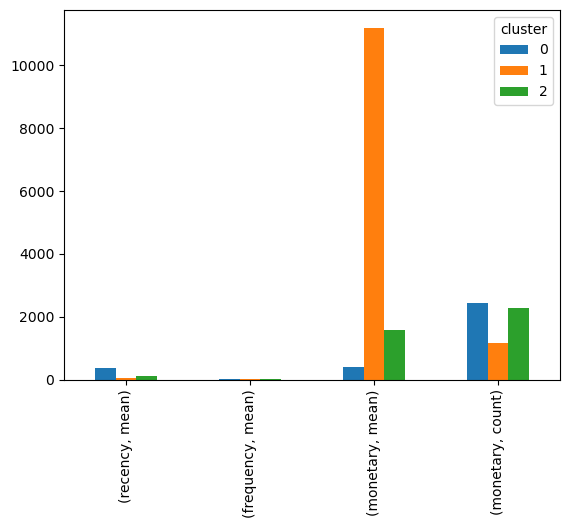

In [101]:
cluster_profile.T.plot(kind='bar')

In [105]:
# Evaluating the model

from sklearn.metrics import silhouette_score

score = silhouette_score(rfm_scaled, cluster)

print(score)

0.34901292898637803
